In [1]:
import os
from glob import glob
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import numpy as np
from collections import OrderedDict

from spectral.io import envi

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry
import logging

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

%matplotlib widget

In [3]:
# load all relevant data

home = '/store/carroll/col/data/'
base_dir_reference = os.path.join(home, '2018/test_roi/calTarp/')
base_dir_test = os.path.join(home, '2018/test_rccs/')

# calibration tarp insitu ASD
insitu = pd.read_csv(os.path.join(home, 'cal_spec_20182025_neon.csv'))

# raw rccs
with open(os.path.join(home, '2018/test_roi/rccs_white_tarp_20250829.pkl'), 'rb') as f: # per-flightline
    rccs = pickle.load(f)
rcc = np.loadtxt(os.path.join(home, '2018/test_roi/rcc_white_tarp_mean_20250829.txt')) # mean across 4 calibration flightlines

# reference targets (calibration tarps)
with open(os.path.join(home, '2018/test_roi/single_pxs.pkl'), 'rb') as f:
    reference_px = pickle.load(f)
    
# bright, dark targets visually selected from multiple flightlines
with open(os.path.join(home, '2018/test_rccs/single_pxs.pkl'), 'rb') as f:
    bright_dark_px = pickle.load(f)

# prep wavelengths
wl = np.array([float(x) for x in envi.read_envi_header(glob(os.path.join(base_dir_reference, '*/input/*_rdn.hdr'))[0])['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

In [4]:
# check available flight ids 
reference_flights = [x for x in os.listdir(base_dir_reference) if x.startswith('NIS')]
reference_flights = ['_'.join(x.split('_')[:3]) for x in reference_flights]
test_flights = [x for x in os.listdir(base_dir_test) if x.startswith('NIS')]

print('base_dir_reference \n', reference_flights, '\n')
print('base_dir_test \n', test_flights)

base_dir_reference 
 ['NIS01_20180611_172310', 'NIS01_20180611_172711', 'NIS01_20180611_173116', 'NIS01_20180611_173537'] 

base_dir_test 
 ['NIS01_20180612_173258', 'NIS01_20180612_174155', 'NIS01_20180619_154149', 'NIS01_20180619_155226', 'NIS01_20180620_170133']


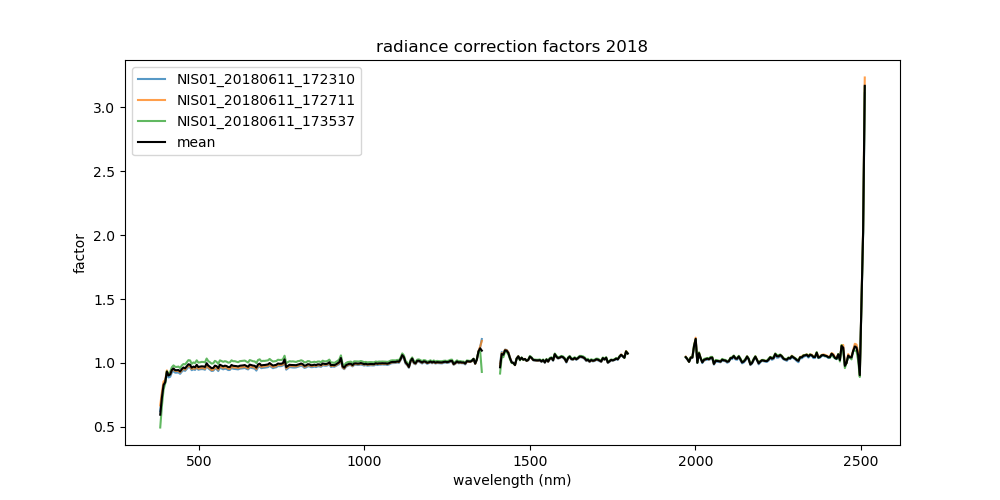

In [5]:
## viz rccs

fig = plt.figure(figsize=(10,5))
for flight in rccs.keys():
    try:
        rcc_ = rccs[flight]['white_tarp']
        plt.plot(wl_nan, rcc_, label=flight, alpha=0.75)
    except: pass
plt.plot(wl_nan, rcc, color='black', label='mean')
plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.title('radiance correction factors 2018')
plt.legend()
plt.show()

INFO:root:Loading config file: /store/carroll/col/data/2018/test_rccs/NIS01_20180612_174155/config/NIS01_20180612_174155_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_rccs/NIS01_20180612_174155/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


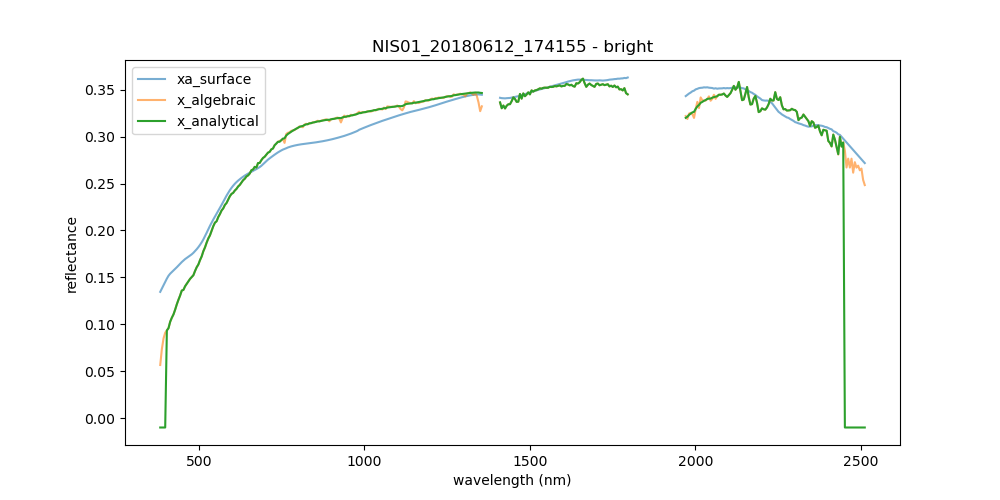

In [12]:
# retrieve rfl w adjusted radiance

base_dir = base_dir_test
flight_id = test_flights[1]
k = 'bright'

working_dir = glob(os.path.join(base_dir, f'{flight_id}*'))[0]

if base_dir==base_dir_reference:
    rdn = reference_px['rdn'][flight_id][k]
    obs = reference_px['obs'][flight_id][k]
    loc = reference_px['loc'][flight_id][k]
else:
    rdn = bright_dark_px[flight_id][k]['rdn']
    obs = bright_dark_px[flight_id][k]['obs']
    loc = bright_dark_px[flight_id][k]['loc']

# load config as-is
fp_config = os.path.join(working_dir, 'config', f'{flight_id}_isofit.json')
config = configs.create_new_config(fp_config)

# set up forward model, io, inversion according to config
fm = ForwardModel(config)
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs, loc=loc)
geom.sky_view_factor = 1 # updated isofit dev 8/20 and now this is necessary? Not sure why skyview factor is no longer automatically populating to 1 when none provided

# adjust rdn
meas = rdn.copy()
meas = meas*rcc

# retrieve rfl
states=inv.invert(meas, geom)
xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
rfl_est = fm.surface.fit_params(x_alg, geom)
x0 = np.concatenate([rfl_est, x_RT, x_instrument])
states, unc, EXIT_CODE = invert_analytical(inv.fm, inv.winidx, meas, geom, np.copy(x0), states[-1,:], num_iter = 1, hash_table = OrderedDict(),hash_size = 500,)
x_analytical = states[-1, fm.idx_surf_rfl]

# viz
fig = plt.figure(figsize=(10,5))
plt.plot(wl_nan, xa_surface, label='xa_surface', alpha=0.6)
plt.plot(wl_nan, x_alg, label='x_algebraic', alpha=0.6)
plt.plot(wl_nan, x_analytical, label='x_analytical')
plt.title(f'{flight_id} - {k}')
plt.ylabel('reflectance')
plt.xlabel('wavelength (nm)')
plt.legend()
plt.show()

In [ ]:
# retrieve rfl w adjusted radiance

base_dir = base_dir_test
# flight_id = test_flights[1]
# k = 'bright'

alg_rfl = []

for flight_id in test_flights:
    for k in ['bright', 'dark']:
        working_dir = glob(os.path.join(base_dir, f'{flight_id}*'))[0]
        
        if base_dir==base_dir_reference:
            rdn = reference_px['rdn'][flight_id][k]
            obs = reference_px['obs'][flight_id][k]
            loc = reference_px['loc'][flight_id][k]
        else:
            rdn = bright_dark_px[flight_id][k]['rdn']
            obs = bright_dark_px[flight_id][k]['obs']
            loc = bright_dark_px[flight_id][k]['loc']
        
        # load config as-is
        fp_config = os.path.join(working_dir, 'config', f'{flight_id}_isofit.json')
        config = configs.create_new_config(fp_config)
        
        # set up forward model, io, inversion according to config
        fm = ForwardModel(config)
        io = IO(config, fm)
        inv = Inversion(config, fm)
        
        # load the isofit geometry representation of the single pixel
        geom = Geometry(obs=obs, loc=loc)
        geom.sky_view_factor = 1 # updated isofit dev 8/20 and now this is necessary? Not sure why skyview factor is no longer automatically populating to 1 when none provided
        
        # adjust rdn
        meas = rdn.copy()
        meas = meas*rcc
        
        # retrieve rfl
        states=inv.invert(meas, geom)
        xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
        alg_rfl.append(x_alg)
        # rfl_est = fm.surface.fit_params(x_alg, geom)
        # x0 = np.concatenate([rfl_est, x_RT, x_instrument])
        # states, unc, EXIT_CODE = invert_analytical(inv.fm, inv.winidx, meas, geom, np.copy(x0), states[-1,:], num_iter = 1, hash_table = OrderedDict(),hash_size = 500,)
        # x_analytical = states[-1, fm.idx_surf_rfl]

# # viz
# fig = plt.figure(figsize=(10,5))
# plt.plot(wl_nan, xa_surface, label='xa_surface', alpha=0.6)
# plt.plot(wl_nan, x_alg, label='x_algebraic', alpha=0.6)
# plt.plot(wl_nan, x_analytical, label='x_analytical')
# plt.title(f'{flight_id} - {k}')
# plt.ylabel('reflectance')
# plt.xlabel('wavelength (nm)')
# plt.legend()
# plt.show()

INFO:root:Loading config file: /store/carroll/col/data/2018/test_rccs/NIS01_20180612_173258/config/NIS01_20180612_173258_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_rccs/NIS01_20180612_173258/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: /store/carroll/col/data/2018/test_rccs/NIS01_20180612_173258/config/NIS01_20180612_173258_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_

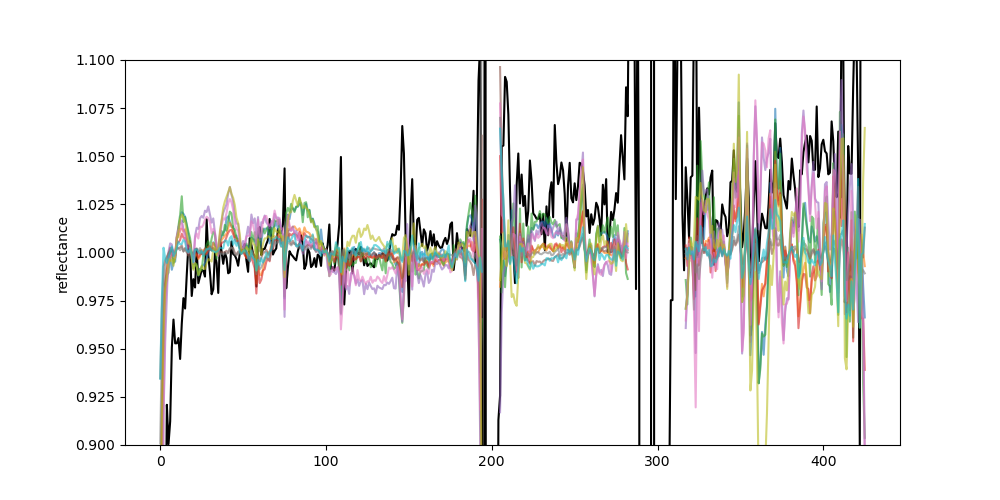

In [40]:
# viz
fig = plt.figure(figsize=(10,5))

exp_arr = np.array([5,10,20,35,50,75,100,150,180,210,220,250,260,280,320,340,355,380,400,420])
bin_size = 2

plt.plot(rcc, color='black')

for i in range(len(alg_rfl)):
    # plt.plot(alg_rfl[i], label=f'x_algebraic {i}', alpha=0.6)
    exp_lis = [np.mean(wl_nan[x-bin_size:x+bin_size]) for x in exp_arr]
    rfl_lis = [np.mean(alg_rfl[i][x-bin_size:x+bin_size]) for x in exp_arr]
    plt.plot((np.interp(wl_nan, exp_lis, rfl_lis)+alg_rfl[i])*5+1, label=f'x_algebraic {i}', alpha=0.6)
plt.ylabel('reflectance')
# plt.xlabel('wavelength (nm)')
plt.ylim(0.9, 1.1)
# plt.legend()
plt.show()